# 03 – Exploratory Data Analysis
**Bluestock Fintech Mutual Fund Analytics Platform**

15+ professional charts covering NAV trends, AUM, SIP, demographics, geography, and sector allocation.

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.dpi": 130, "axes.spines.top": False, "axes.spines.right": False,
    "font.family": "DejaVu Sans", "axes.titlesize": 12, "axes.labelsize": 10
})
sns.set_palette("husl")

BASE = Path("..").resolve()
PROC = BASE / "data" / "processed"
RPT  = BASE / "reports"
RPT.mkdir(exist_ok=True)

# Load datasets
nav    = pd.read_csv(PROC / "nav_history_clean.csv", parse_dates=["date"])
aum    = pd.read_csv(PROC / "aum_by_fund_house_clean.csv", parse_dates=["date"])
sip    = pd.read_csv(PROC / "monthly_sip_inflows_clean.csv", parse_dates=["month"])
cat    = pd.read_csv(PROC / "category_inflows_clean.csv", parse_dates=["month"])
folio  = pd.read_csv(PROC / "industry_folio_count_clean.csv", parse_dates=["month"])
sp     = pd.read_csv(PROC / "scheme_performance_clean.csv")
txn    = pd.read_csv(PROC / "investor_transactions_clean.csv", parse_dates=["transaction_date"])
hold   = pd.read_csv(PROC / "portfolio_holdings_clean.csv")
bench  = pd.read_csv(PROC / "benchmark_indices_clean.csv", parse_dates=["date"])
master = pd.read_csv(PROC / "fund_master_clean.csv")
print("All datasets loaded for EDA.")

All datasets loaded for EDA.


## Chart 1 – NAV Trend for Top 5 Funds by AUM

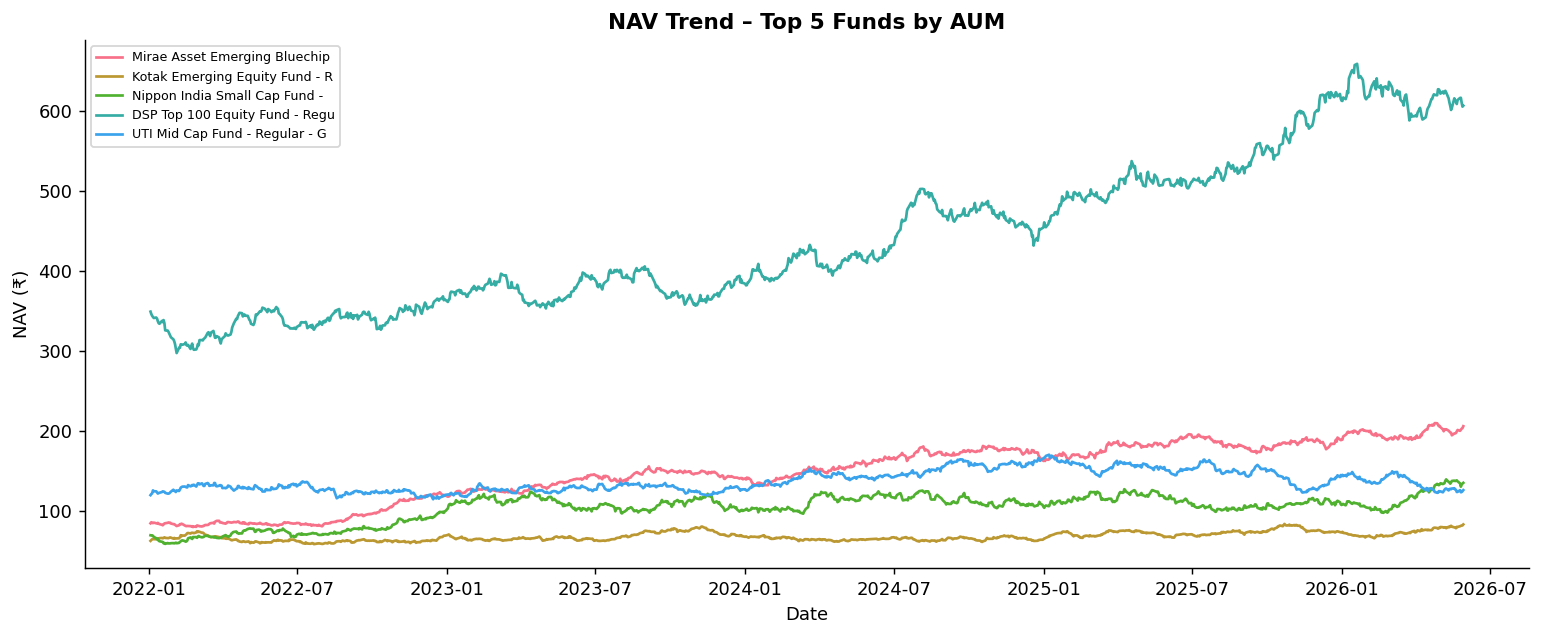

In [17]:
top5 = sp.nlargest(5, "aum_crore")["amfi_code"].tolist()
fig, ax = plt.subplots(figsize=(12, 5))
for code in top5:
    sub = nav[nav["amfi_code"] == code].sort_values("date")
    name = sp[sp["amfi_code"]==code]["scheme_name"].values
    label = name[0][:30] if len(name) else str(code)
    ax.plot(sub["date"], sub["nav"], label=label, linewidth=1.5)
ax.set_title("NAV Trend – Top 5 Funds by AUM", fontweight="bold")
ax.set_xlabel("Date"); ax.set_ylabel("NAV (₹)")
ax.legend(fontsize=7, loc="upper left")
plt.tight_layout()
plt.savefig(RPT / "chart01_nav_trend_top5.png", dpi=150)
plt.show()

## Chart 2 – Total AUM Trend (Industry Level)

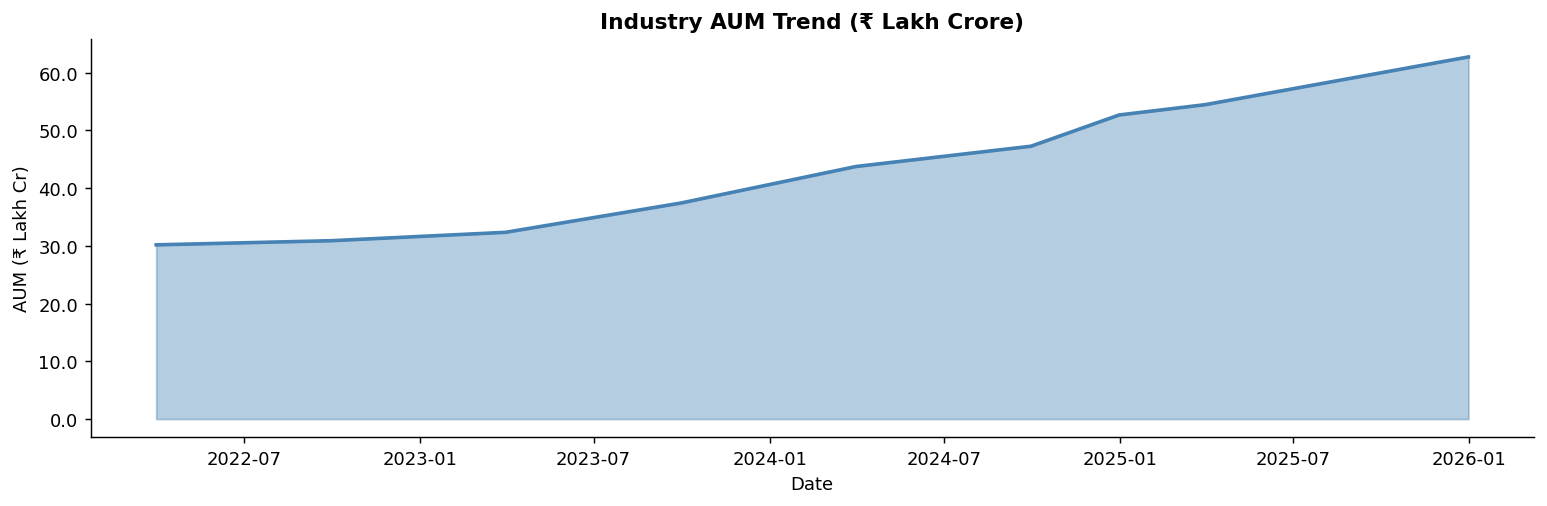

In [18]:
aum_monthly = aum.groupby("date")["aum_crore"].sum().reset_index()
fig, ax = plt.subplots(figsize=(12,4))
ax.fill_between(aum_monthly["date"], aum_monthly["aum_crore"]/1e5, alpha=0.4, color="steelblue")
ax.plot(aum_monthly["date"], aum_monthly["aum_crore"]/1e5, color="steelblue", linewidth=2)
ax.set_title("Industry AUM Trend (₹ Lakh Crore)", fontweight="bold")
ax.set_xlabel("Date"); ax.set_ylabel("AUM (₹ Lakh Cr)")
ax.yaxis.set_major_formatter(mtick.FormatStrFormatter("%.1f"))
plt.tight_layout()
plt.savefig(RPT / "chart02_aum_trend.png", dpi=150)
plt.show()

## Chart 3 – Monthly SIP Inflow Trend

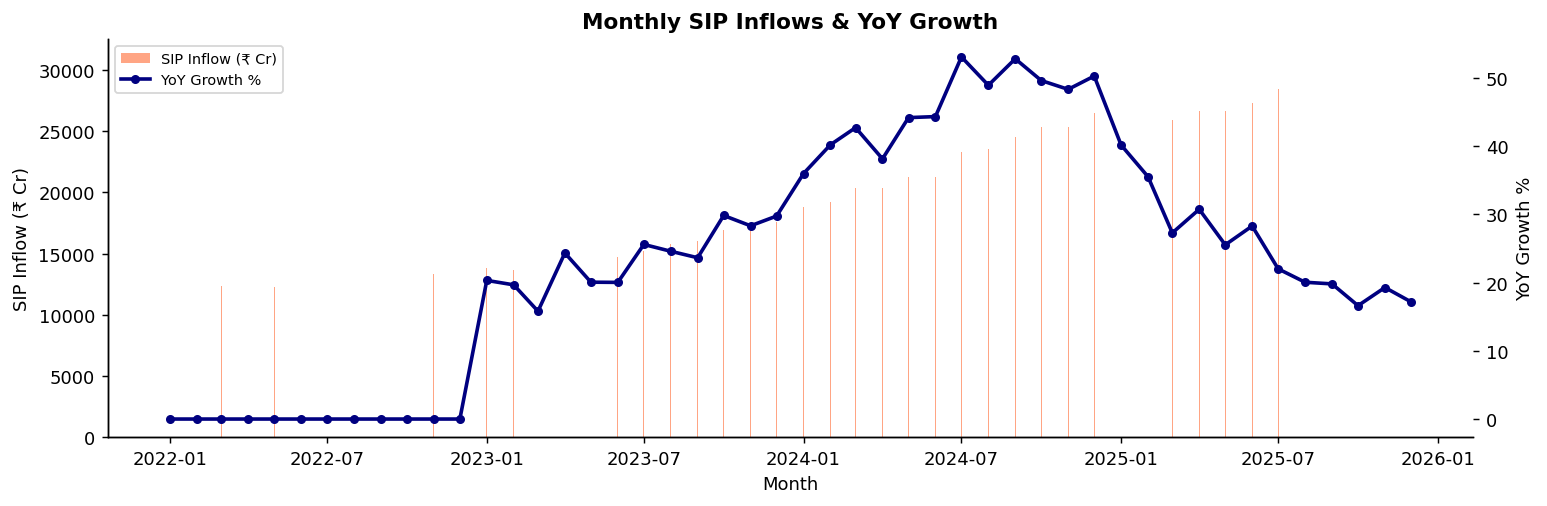

In [19]:
fig, ax1 = plt.subplots(figsize=(12,4))
ax2 = ax1.twinx()
bars = ax1.bar(sip["month"], sip["sip_inflow_crore"], color="coral", alpha=0.7, label="SIP Inflow (₹ Cr)")
ax2.plot(sip["month"], sip["yoy_growth_pct"], color="navy", linewidth=2, marker="o", ms=4, label="YoY Growth %")
ax1.set_title("Monthly SIP Inflows & YoY Growth", fontweight="bold")
ax1.set_xlabel("Month"); ax1.set_ylabel("SIP Inflow (₹ Cr)"); ax2.set_ylabel("YoY Growth %")
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines+lines2, labels+labels2, loc="upper left", fontsize=8)
plt.tight_layout()
plt.savefig(RPT / "chart03_sip_trend.png", dpi=150)
plt.show()

## Chart 4 – Category Net Inflows (Latest 6 Months)

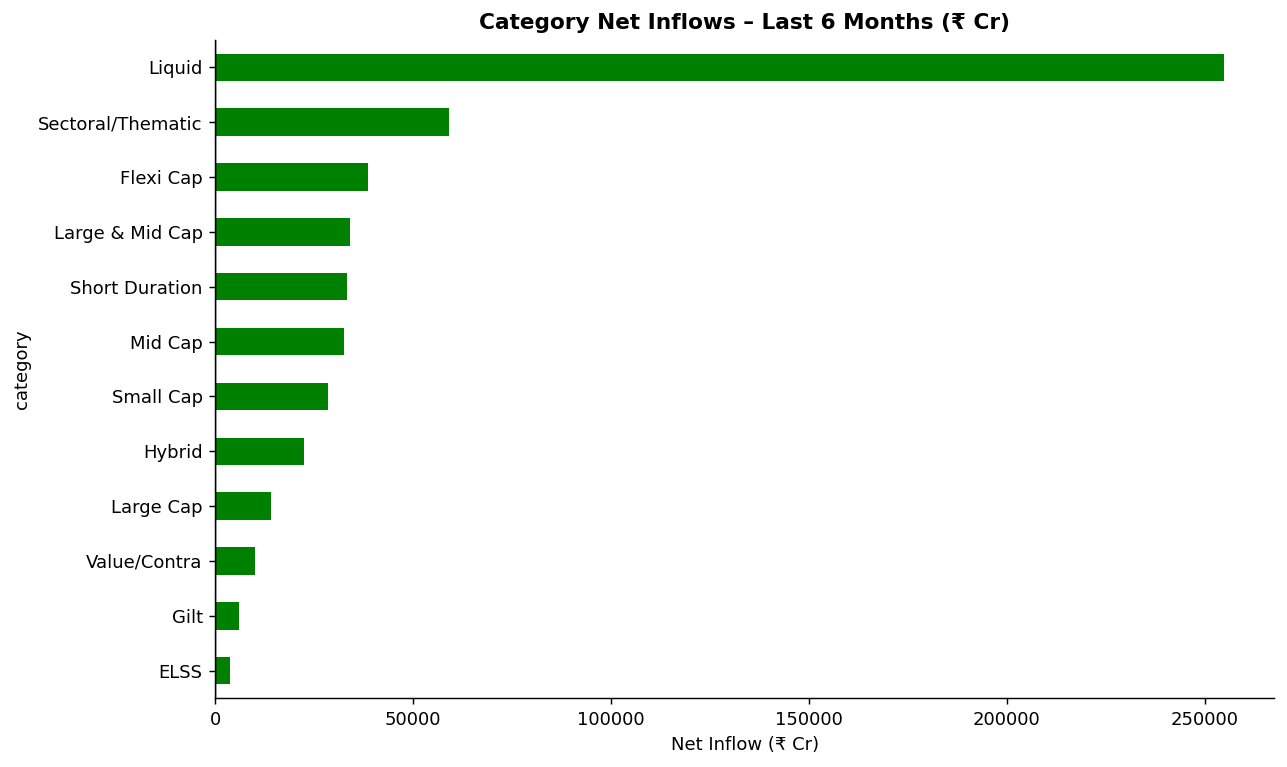

In [20]:
cat_latest = cat[cat["month"] >= cat["month"].max() - pd.DateOffset(months=6)]
cat_sum = cat_latest.groupby("category")["net_inflow_crore"].sum().sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(10,6))
colors = ["red" if v < 0 else "green" for v in cat_sum]
cat_sum.plot(kind="barh", ax=ax, color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Category Net Inflows – Last 6 Months (₹ Cr)", fontweight="bold")
ax.set_xlabel("Net Inflow (₹ Cr)")
plt.tight_layout()
plt.savefig(RPT / "chart04_category_inflows.png", dpi=150)
plt.show()

## Chart 5 – Investor Age Group Distribution

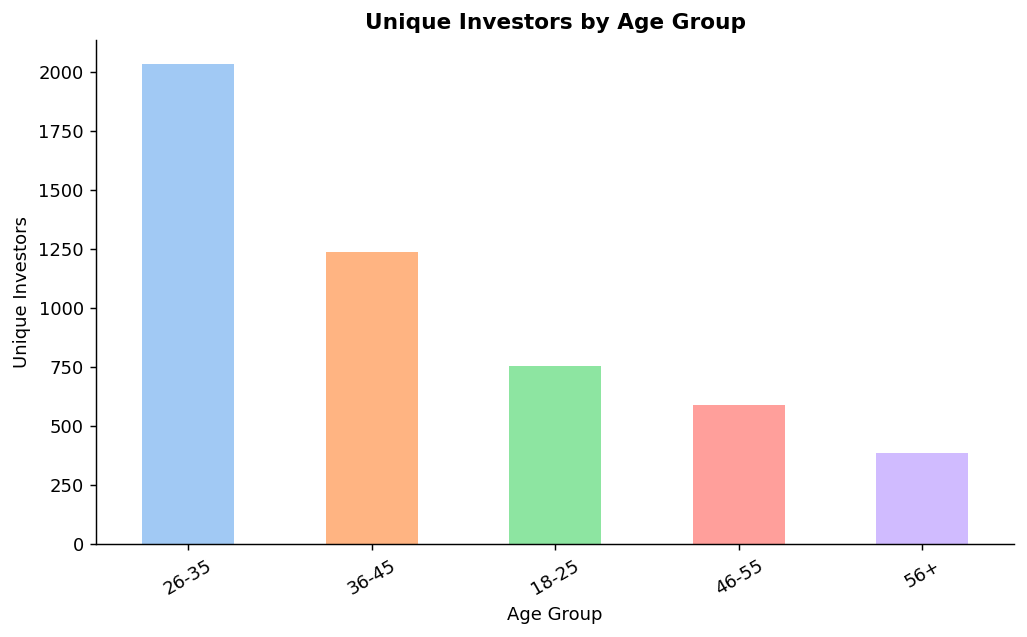

In [21]:
age_dist = txn.groupby("age_group")["investor_id"].nunique().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8,5))
age_dist.plot(kind="bar", ax=ax, color=sns.color_palette("pastel"))
ax.set_title("Unique Investors by Age Group", fontweight="bold")
ax.set_xlabel("Age Group"); ax.set_ylabel("Unique Investors")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.savefig(RPT / "chart05_age_distribution.png", dpi=150)
plt.show()

## Chart 6 – Gender Split (Pie)

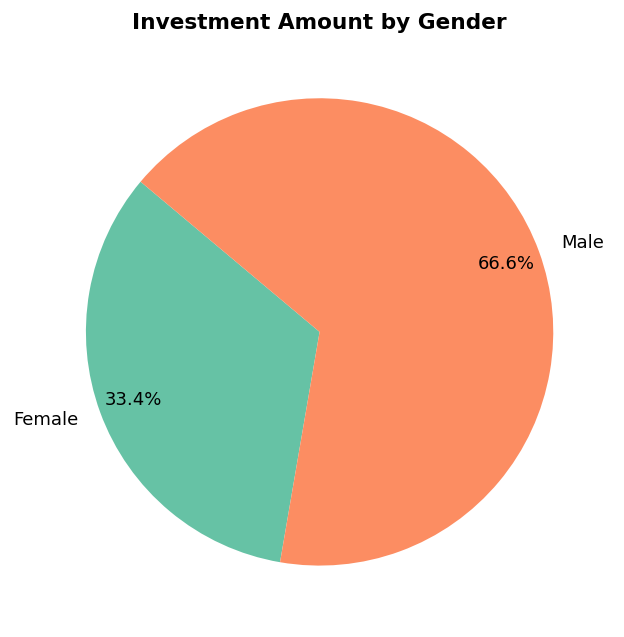

In [22]:
gender_invest = txn.groupby("gender")["amount_inr"].sum()
fig, ax = plt.subplots(figsize=(6,5))
ax.pie(gender_invest, labels=gender_invest.index, autopct="%1.1f%%",
       colors=sns.color_palette("Set2"), startangle=140, pctdistance=0.85)
ax.set_title("Investment Amount by Gender", fontweight="bold")
plt.tight_layout()
plt.savefig(RPT / "chart06_gender_split.png", dpi=150)
plt.show()

## Chart 7 – State-wise Investment Heatmap (Top 15)

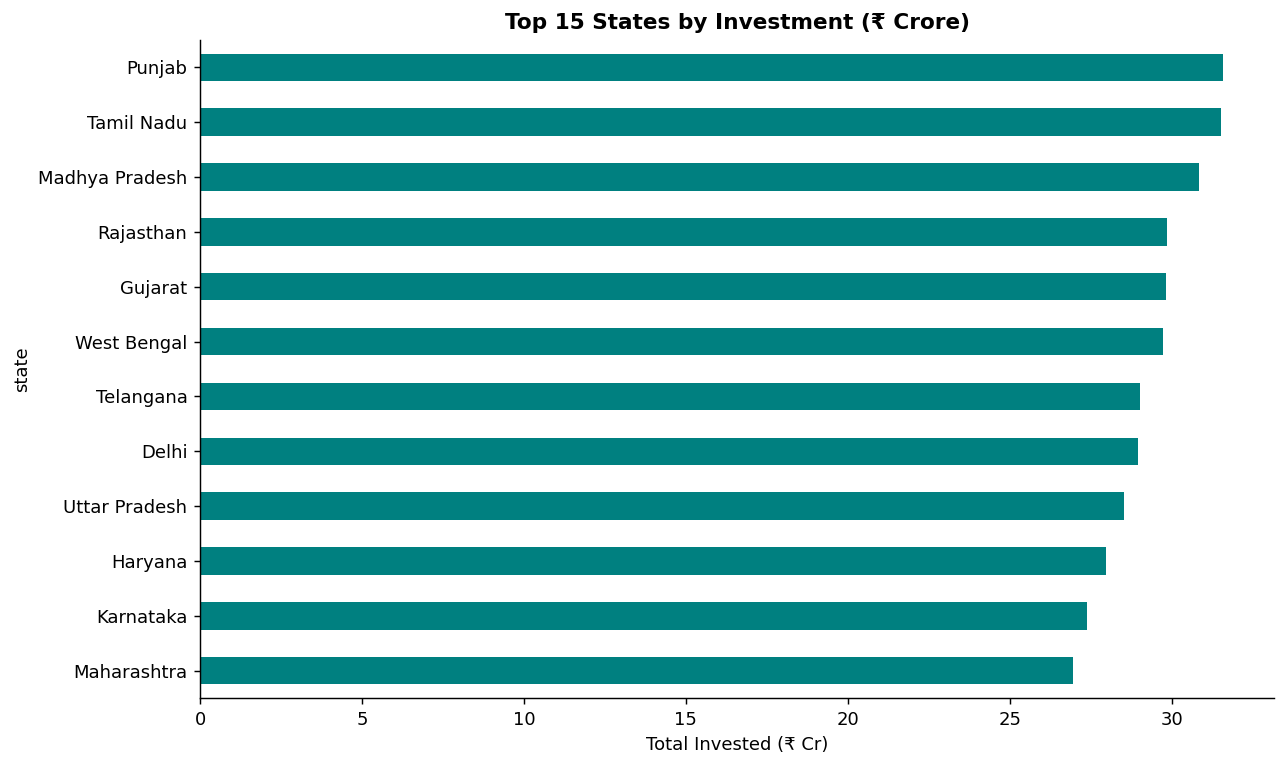

In [23]:
state_inv = txn.groupby("state")["amount_inr"].sum().nlargest(15) / 1e7
fig, ax = plt.subplots(figsize=(10,6))
state_inv.sort_values().plot(kind="barh", ax=ax, color="teal")
ax.set_title("Top 15 States by Investment (₹ Crore)", fontweight="bold")
ax.set_xlabel("Total Invested (₹ Cr)")
plt.tight_layout()
plt.savefig(RPT / "chart07_state_investment.png", dpi=150)
plt.show()

## Chart 8 – Portfolio Sector Allocation

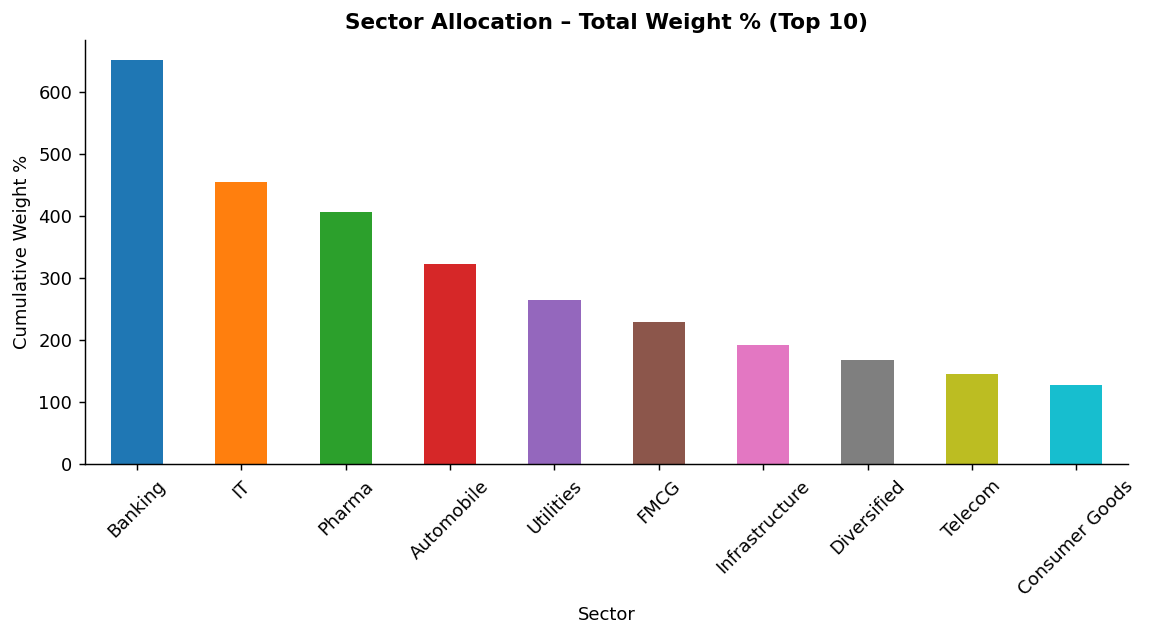

In [24]:
sector_wt = hold.groupby("sector")["weight_pct"].sum().sort_values(ascending=False).head(10)
fig, ax = plt.subplots(figsize=(9,5))
sector_wt.plot(kind="bar", ax=ax, color=sns.color_palette("tab10"))
ax.set_title("Sector Allocation – Total Weight % (Top 10)", fontweight="bold")
ax.set_xlabel("Sector"); ax.set_ylabel("Cumulative Weight %")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.savefig(RPT / "chart08_sector_allocation.png", dpi=150)
plt.show()

## Chart 9 – Correlation Matrix (Scheme Performance Metrics)

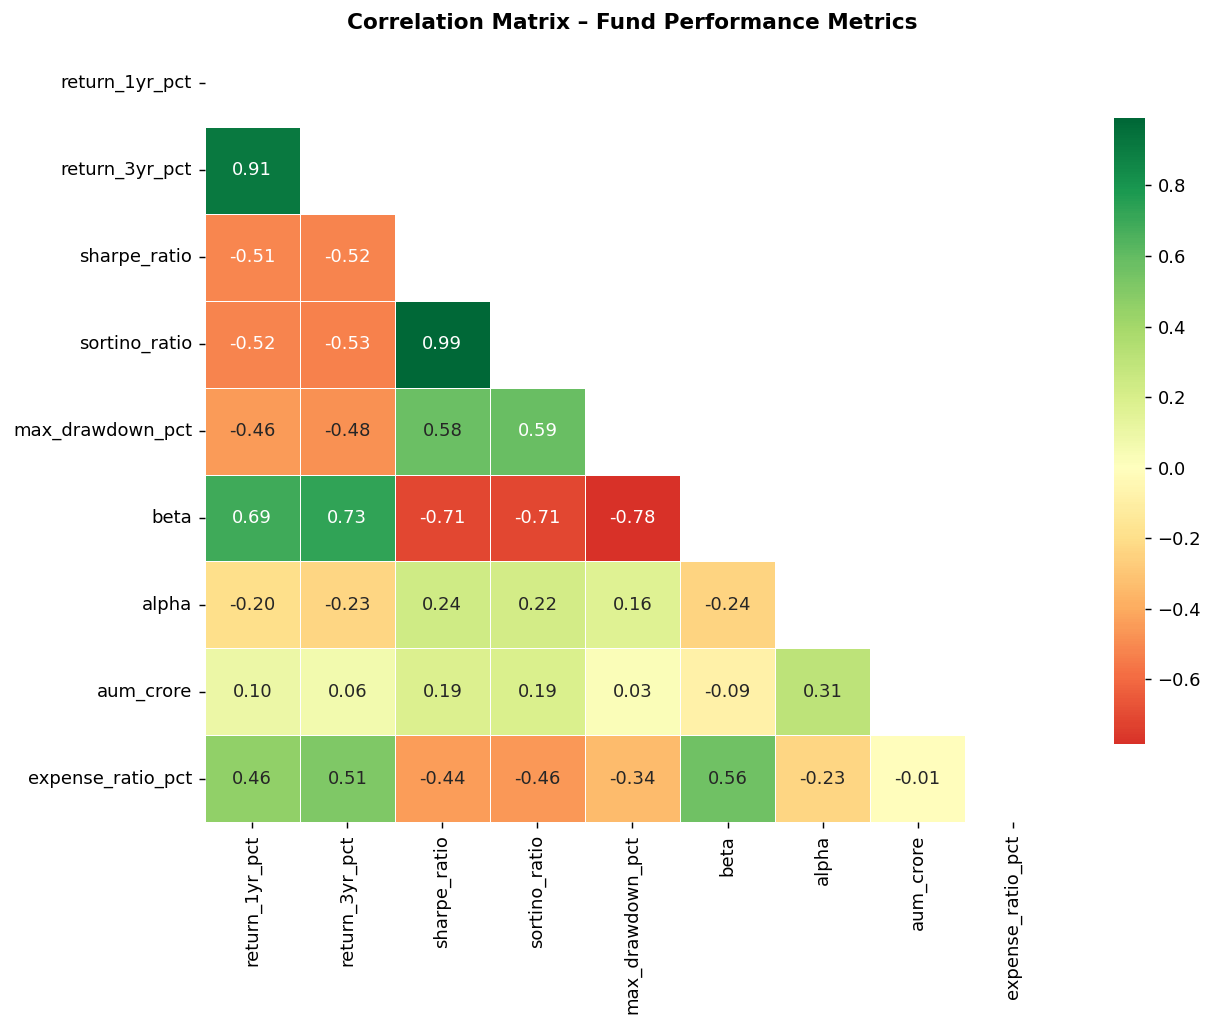

In [25]:
metrics = ["return_1yr_pct","return_3yr_pct","sharpe_ratio","sortino_ratio",
           "max_drawdown_pct","beta","alpha","aum_crore","expense_ratio_pct"]
metrics = [c for c in metrics if c in sp.columns]
corr = sp[metrics].corr()
fig, ax = plt.subplots(figsize=(10,8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdYlGn", center=0,
            mask=mask, ax=ax, linewidths=0.5, cbar_kws={"shrink": 0.8})
ax.set_title("Correlation Matrix – Fund Performance Metrics", fontweight="bold")
plt.tight_layout()
plt.savefig(RPT / "chart09_correlation_matrix.png", dpi=150)
plt.show()

## Chart 10 – AUM by Fund House (Latest Month)

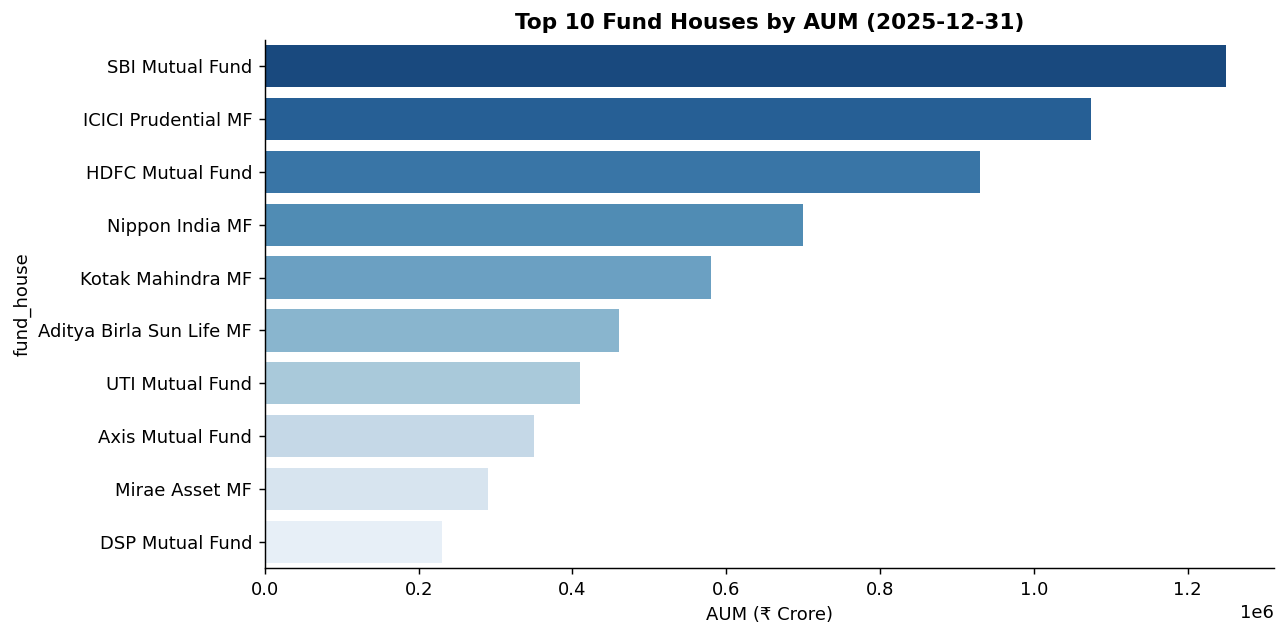

In [26]:
latest_date = aum["date"].max()
aum_latest = aum[aum["date"] == latest_date].nlargest(10, "aum_crore")
fig, ax = plt.subplots(figsize=(10,5))
sns.barplot(data=aum_latest, x="aum_crore", y="fund_house", ax=ax, palette="Blues_r")
ax.set_title(f"Top 10 Fund Houses by AUM ({latest_date.date()})", fontweight="bold")
ax.set_xlabel("AUM (₹ Crore)")
plt.tight_layout()
plt.savefig(RPT / "chart10_aum_by_fund_house.png", dpi=150)
plt.show()

## Chart 11 – Risk Category Distribution (Pie)

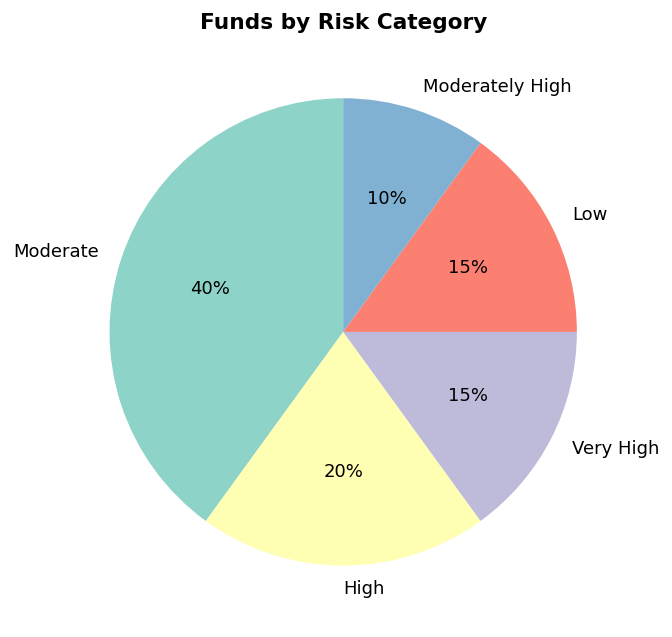

In [27]:
risk_dist = master["risk_category"].value_counts()
fig, ax = plt.subplots(figsize=(7,5))
ax.pie(risk_dist, labels=risk_dist.index, autopct="%1.0f%%",
       colors=sns.color_palette("Set3"), startangle=90)
ax.set_title("Funds by Risk Category", fontweight="bold")
plt.tight_layout()
plt.savefig(RPT / "chart11_risk_category_dist.png", dpi=150)
plt.show()

## Chart 12 – Benchmark Index Performance

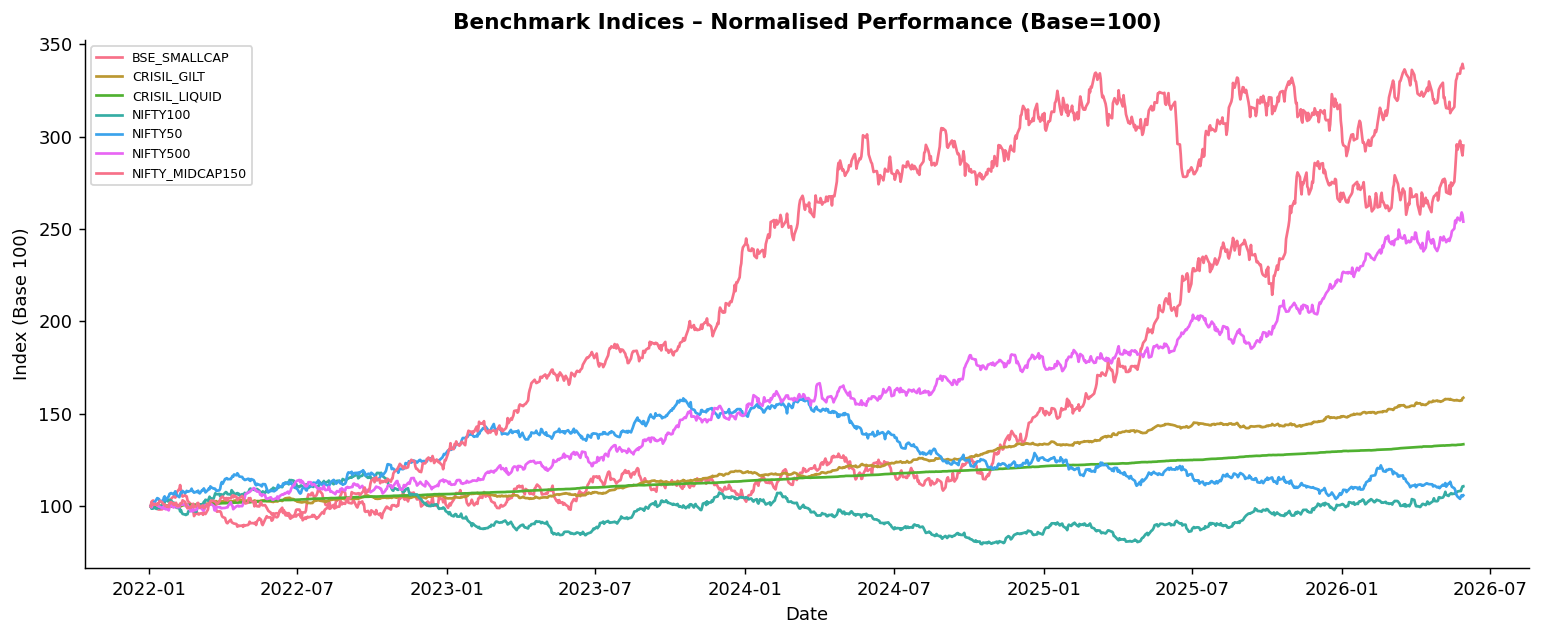

In [28]:
fig, ax = plt.subplots(figsize=(12,5))
for idx_name, grp in bench.groupby("index_name"):
    grp = grp.sort_values("date")
    normalized = grp["close_value"] / grp["close_value"].iloc[0] * 100
    ax.plot(grp["date"], normalized, label=idx_name, linewidth=1.5)
ax.set_title("Benchmark Indices – Normalised Performance (Base=100)", fontweight="bold")
ax.set_xlabel("Date"); ax.set_ylabel("Index (Base 100)")
ax.legend(fontsize=7)
plt.tight_layout()
plt.savefig(RPT / "chart12_benchmark_performance.png", dpi=150)
plt.show()

## Chart 13 – Transaction Type Breakdown

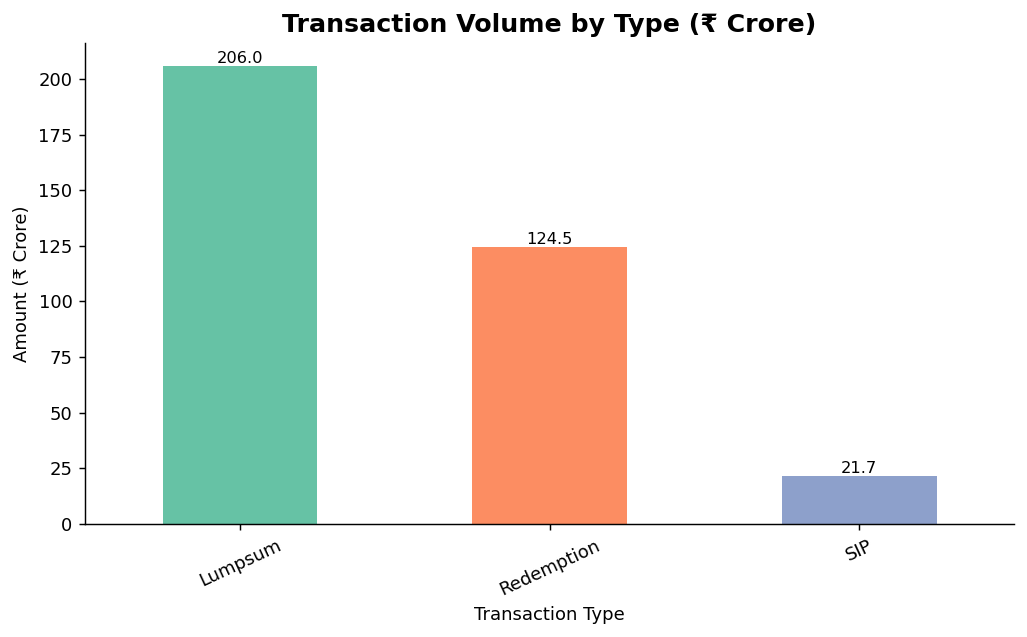

Chart Saved Successfully!


In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Transaction Volume by Type (₹ Crore)

txn_type = (
    txn.groupby("transaction_type")["amount_inr"]
    .sum()
    .sort_values(ascending=False)
    / 1e7
)

fig, ax = plt.subplots(figsize=(8, 5))

colors = sns.color_palette("Set2", n_colors=len(txn_type))

txn_type.plot(
    kind="bar",
    ax=ax,
    color=colors
)

ax.set_title(
    "Transaction Volume by Type (₹ Crore)",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("Transaction Type")
ax.set_ylabel("Amount (₹ Crore)")

ax.tick_params(
    axis="x",
    rotation=25
)

# Add value labels
for i, v in enumerate(txn_type.values):
    ax.text(
        i,
        v,
        f"{v:.1f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()

# Save chart
plt.savefig(
    RPT / "chart13_transaction_types.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print("Chart Saved Successfully!")

## Chart 14 – Folio Growth Trend

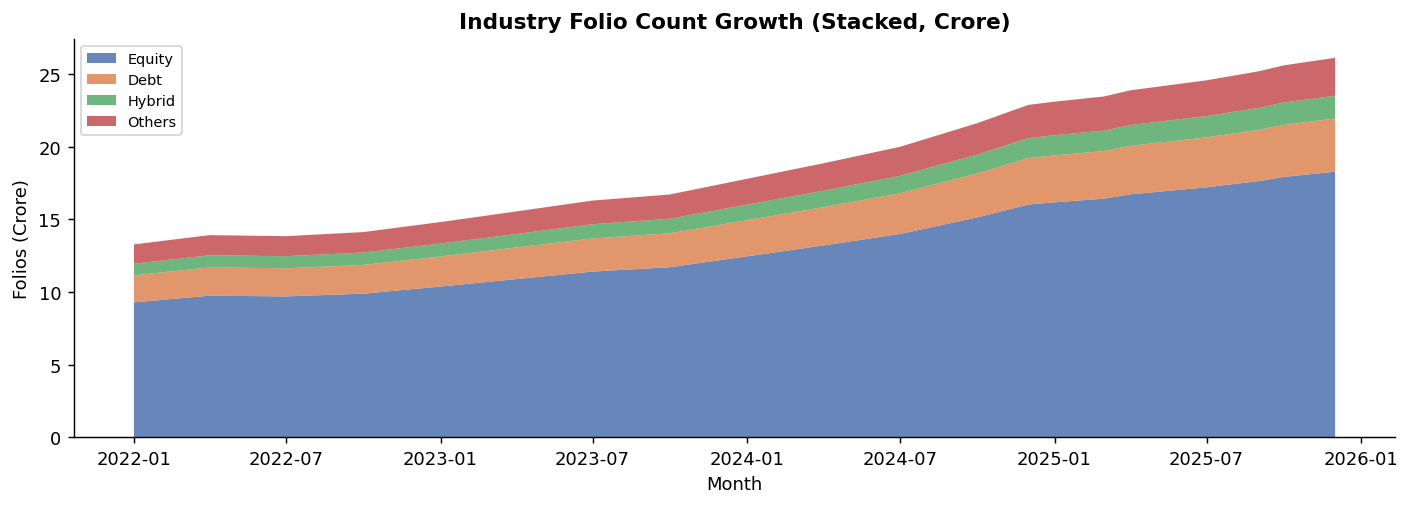

In [30]:
fig, ax = plt.subplots(figsize=(11,4))
ax.stackplot(folio["month"],
             folio["equity_folios_crore"], folio["debt_folios_crore"],
             folio["hybrid_folios_crore"], folio["others_folios_crore"],
             labels=["Equity","Debt","Hybrid","Others"],
             colors=["#4C72B0","#DD8452","#55A868","#C44E52"], alpha=0.85)
ax.set_title("Industry Folio Count Growth (Stacked, Crore)", fontweight="bold")
ax.set_xlabel("Month"); ax.set_ylabel("Folios (Crore)")
ax.legend(loc="upper left", fontsize=8)
plt.tight_layout()
plt.savefig(RPT / "chart14_folio_growth.png", dpi=150)
plt.show()

## Chart 15 – Return Distribution (1Y vs 3Y)

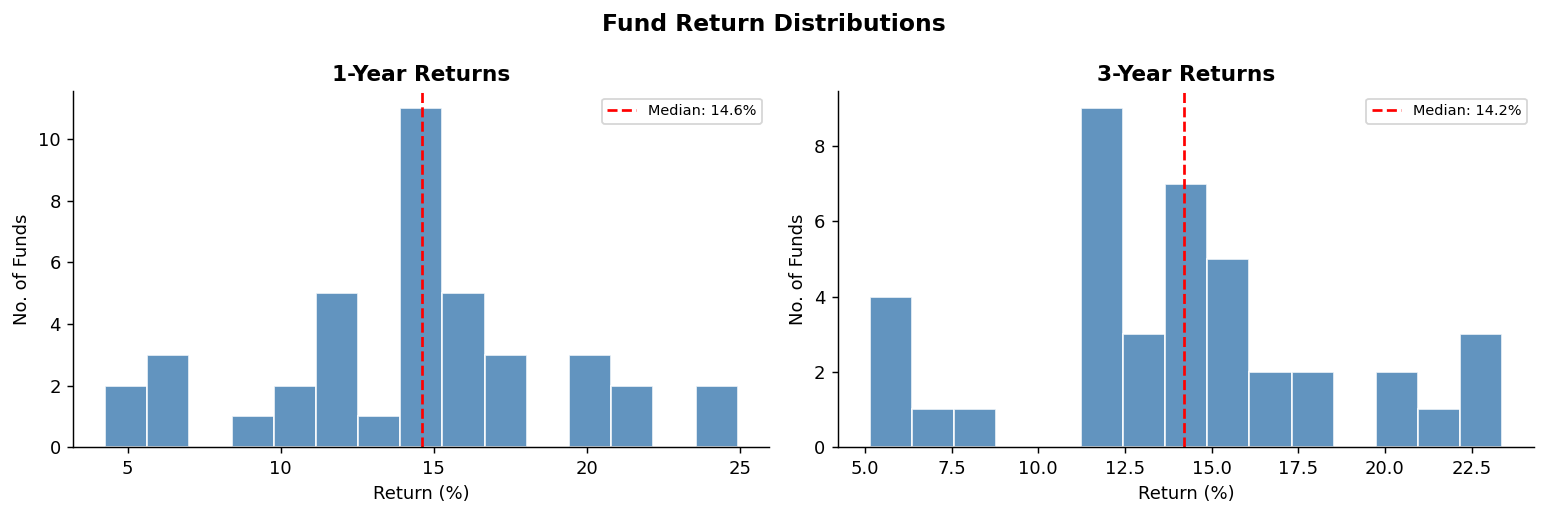


All 15 EDA charts saved in reports/


In [31]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col, title in zip(axes, ["return_1yr_pct","return_3yr_pct"],
                           ["1-Year Returns","3-Year Returns"]):
    data = sp[col].dropna()
    ax.hist(data, bins=15, color="steelblue", edgecolor="white", alpha=0.85)
    ax.axvline(data.median(), color="red", linestyle="--", linewidth=1.5, label=f"Median: {data.median():.1f}%")
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("Return (%)"); ax.set_ylabel("No. of Funds")
    ax.legend(fontsize=8)
plt.suptitle("Fund Return Distributions", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(RPT / "chart15_return_distributions.png", dpi=150)
plt.show()
print("\nAll 15 EDA charts saved in reports/")